## Section 1: Environment Setup & Reproducibility

In [1]:
import preprocess
import numpy as np
import collections
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import random
import os
import scipy.stats as stats

In [2]:
def set_deterministic_seeds(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Force PyTorch algorithms to be deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[*] Global seed locked to {seed}. Deep learning pipeline is now fully reproducible.")

set_deterministic_seeds(42)

[*] Global seed locked to 42. Deep learning pipeline is now fully reproducible.


## Section 2: Data Loading & Strategic Downsampling
*Loading and preprocessing the (CICIDS-2017 Thursday subset).*

In [3]:
# 1. Clean the file (Replace with your actual raw Thursday CSV filename)
raw_file_name = "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
cleaned_dataframe = preprocess.load_and_clean_dataset(raw_file_name)

# 2. Extract our structured data splits
# We downsample the massive file to 30,000 stratified samples so SHAP calculations remain immediate
X_train, X_test, y_train, y_test, feature_names = preprocess.prepare_splits(cleaned_dataframe, sample_size=30000)

# 3. Sanity check: verify our binary shortcut label counters
print("\nFinal Target Class Breakdown (0 = Safe Benign, 1 = Web Attack Anomaly):")
print(collections.Counter(y_train))

[*] Loading raw dataset from: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\preprocess.py:12: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin-1')


[-] Dropped identifier columns: ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
[!] Purged 288737 malformed rows containing Infinity or empty cells.
[*] Applying strategic downsampling to a subset of 30000 rows...
[*] Preprocessing complete. Pipeline breakdown:
    -> Training set size: 24000 rows
    -> Evaluation test set size: 6000 rows
    -> Feature metrics tracking: 78 individual features

Final Target Class Breakdown (0 = Safe Benign, 1 = Web Attack Anomaly):
Counter({np.int64(0): 23693, np.int64(1): 307})


## Section 3: Baseline IDS Classifier (XGBoost Architecture)
*Training the tree-based model with class imbalance adjustment factors.*

In [ ]:


# 1. Compute the structural balance ratio to balance gradient penalties
num_benign = np.sum(y_train == 0)
num_attacks = np.sum(y_train == 1)
balance_weight = num_benign / num_attacks

print(f"[*] Calculated class imbalance weight: {balance_weight:.2f}")
print("[*] Initializing XGBoost tree engine architecture...")

# 2. Build the model with hyperparameter standards from network security literature
xgb_model = XGBClassifier(
    n_estimators=100,          # Total gradient trees compiled
    max_depth=6,               # Tree structure depth threshold to prevent overfitting
    learning_rate=0.1,         # Step size shrinkage to guard consistency
    scale_pos_weight=balance_weight, # Internal balance anchor
    random_state=42,           # Freezes data seeding for replicable results
    eval_metric='logloss'
)

print("[*] Training XGBoost model on continuous feature matrices...")
xgb_model.fit(X_train, y_train)
print("[+] XGBoost baseline training complete!")

# 3. Predict classifications on the isolated, clean testing set
y_pred = xgb_model.predict(X_test)

# 4. Generate evaluation matrices for report documentation
print("\n" + "="*20 + " IDS PERFORMANCE REPORT " + "="*20)
print(classification_report(y_test, y_pred, target_names=['Benign (Class 0)', 'Web Attack (Class 1)']))

# Calculate exact confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Diagnostics: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

[*] Calculated class imbalance weight: 77.18
[*] Initializing XGBoost tree engine architecture...
[*] Training XGBoost model on continuous feature matrices...
[+] XGBoost baseline training complete!

==================== IDS PERFORMANCE REPORT ====================
                      precision    recall  f1-score   support

    Benign (Class 0)       1.00      1.00      1.00      5923
Web Attack (Class 1)       0.99      0.95      0.97        77

            accuracy                           1.00      6000
           macro avg       0.99      0.97      0.98      6000
        weighted avg       1.00      1.00      1.00      6000

Diagnostics: TN=5922, FP=1, FN=4, TP=73


## Section 4: Local Attribution Evaluation (XAI Pipeline)
*Isolating True Positive validation flags to extract baseline SHAP and LIME profiles.*

In [5]:
# Locate positions where ground truth is an attack (1) AND the model predicted an attack (1)
true_positive_indices = np.where((y_test == 1) & (y_pred == 1))[0]

print(f"[*] Found {len(true_positive_indices)} True Positive web attack alerts inside the test split.")

# Extract a small slice of these actual alert records to use for our XAI experiments
# We will grab the first 10 for rapid prototyping, as SHAP/LIME calculation can be heavy
alert_instances_to_explain = X_test.iloc[true_positive_indices]
alert_ground_truth = y_test[true_positive_indices]

print("[+] Isolated top test instances for local attribution modeling.")

[*] Found 73 True Positive web attack alerts inside the test split.
[+] Isolated top test instances for local attribution modeling.


[*] Initializing SHAP TreeExplainer...

[+] Computing explanations for Alert Case #1...
--- SHAP Top Feature Attributions ---


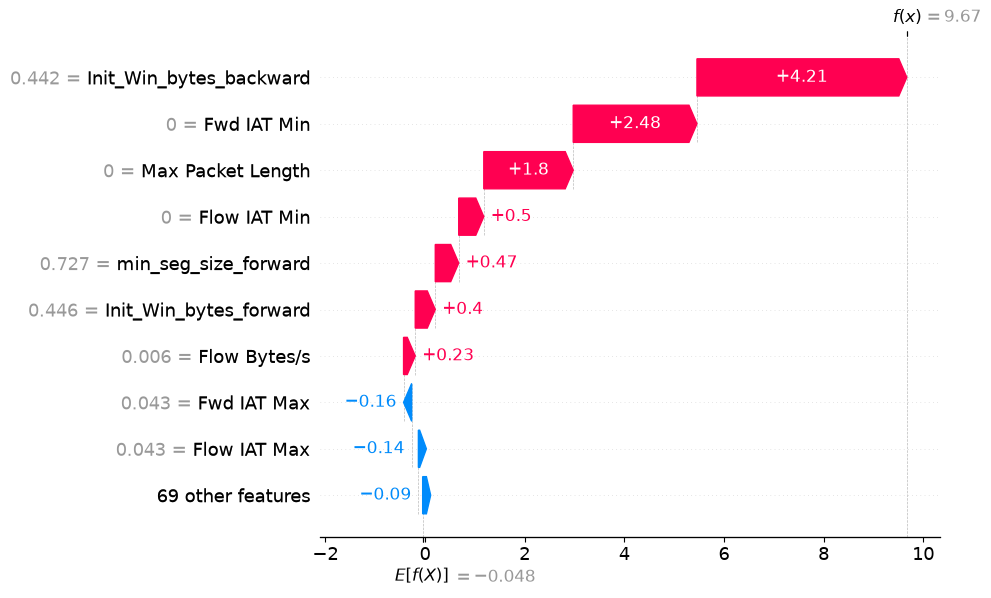

In [6]:


print("[*] Initializing SHAP TreeExplainer...")
# 1. Initialize the tree-optimized SHAP engine
explainer_shap = shap.TreeExplainer(xgb_model)
# Calculate Shapley values for your 10 isolated true positive instances
shap_values = explainer_shap(alert_instances_to_explain)

# 3. Generate and look at an explanation for your very first Web Attack alert instance (Index 0)
print("\n[+] Computing explanations for Alert Case #1...")

# Extract top features for SHAP
# Class 1 means we look at what pushed the prediction towards "Web Attack"
instance_idx = 0
print(f"--- SHAP Top Feature Attributions ---")
shap.plots.waterfall(shap_values[instance_idx], max_display=10)


In [27]:
# 1. Convert your test instances to NumPy arrays explicitly
# This strips away the confusing Pandas index labels
X_test_numpy = X_test.to_numpy()

# 2. Re-initialize the explainer using the NumPy training array
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),  # Pass the training set as NumPy
    feature_names=feature_names,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    random_state=42
)

# 3. Use the NumPy test array for explanation
instance_idx = 0
print(f"--- LIME Attribution Matrix (Case #{instance_idx}) ---")

exp_lime = explainer_lime.explain_instance(
    data_row=alert_instances_to_explain.values[instance_idx], # Using NumPy indexing
    predict_fn=xgb_model.predict_proba,
    num_features=len(feature_names)
)

# Print results
for feature, weight in exp_lime.as_list()[:10]:
    print(f"  -> {feature}: {weight:.4f}")

--- LIME Attribution Matrix (Case #0) ---
  -> 0.00 < Fwd Header Length <= 0.00: 0.0030
  -> Init_Win_bytes_forward > 0.13: 0.0027
  -> 0.00 < Fwd Header Length.1 <= 0.00: 0.0027
  -> 0.00 < Total Fwd Packets <= 0.00: 0.0025
  -> 0.00 < Subflow Fwd Packets <= 0.00: 0.0024
  -> Init_Win_bytes_backward > 0.00: 0.0020
  -> PSH Flag Count > 0.00: 0.0017
  -> Flow Bytes/s <= 0.01: 0.0016
  -> Flow Packets/s <= 0.40: 0.0015
  -> Fwd IAT Mean > 0.00: 0.0015


In [8]:
def calculate_dataset_metrics(shap_values_matrix, lime_values_matrix, feature_names, k=10):
    """
    Computes average Jaccard Similarity, Top-K Feature Overlap, and 
    Spearman Rank Correlation across all provided true positive alert instances.
    Works seamlessly for both XGBoost and Deep Neural Network explanation runs.
    """
    all_overlaps = []
    all_jaccards = []
    all_spearmans = []
    
    num_instances = shap_values_matrix.shape[0]
    
    for i in range(num_instances):
        shap_vec = shap_values_matrix[i]
        lime_vec = lime_values_matrix[i]
        
        # 1. Extract Top-K feature names based on absolute magnitude
        top_k_shap_idx = np.argsort(np.abs(shap_vec))[-k:][::-1]
        top_k_lime_idx = np.argsort(np.abs(lime_vec))[-k:][::-1]
        
        set_shap = set([feature_names[idx] for idx in top_k_shap_idx])
        set_lime = set([feature_names[idx] for idx in top_k_lime_idx])
        
        # 2. Compute Top-K Intersection Metrics
        intersection = set_shap.intersection(set_lime)
        union = set_shap.union(set_lime)
        
        overlap_count = len(intersection)
        jaccard_idx = overlap_count / len(union) if len(union) > 0 else 0
        
        # 3. Compute Structural Rank Agreement (Spearman's Rho) over all features
        rho, _ = stats.spearmanr(shap_vec, lime_vec)
        if np.isnan(rho):
            rho = 0.0  # Safe fallback for uniform local linear regions
            
        all_overlaps.append(overlap_count)
        all_jaccards.append(jaccard_idx)
        all_spearmans.append(rho)
        
    # Return descriptive metric dictionaries for markdown logging
    return {
        "mean_overlap": np.mean(all_overlaps),
        "mean_jaccard": np.mean(all_jaccards),
        "mean_spearman": np.mean(all_spearmans)
    }

def plot_local_explanations_side_by_side(shap_vector, lime_vector, feature_names, instance_id=0, k=10):
    """
    Generates high-contrast side-by-side horizontal bar plots matching academic 
    formatting standards. Features are ordered by absolute contribution. 
    Bars are colored dynamically: Crimson for positive risk impact, Slate Blue for negative.
    """
    # Isolate absolute top contributors
    shap_top_idx = np.argsort(np.abs(shap_vector))[-k:][::-1]
    lime_top_idx = np.argsort(np.abs(lime_vector))[-k:][::-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=False)
    
    # --- Plot Subfigure 1: SHAP Attributions ---
    shap_features = [feature_names[i] for i in shap_top_idx][::-1]
    shap_weights = [shap_vector[i] for i in shap_top_idx][::-1]
    shap_colors = ['#d62728' if w >= 0 else '#1f77b4' for w in shap_weights]
    
    axes[0].barh(shap_features, shap_weights, color=shap_colors, edgecolor='k', alpha=0.85)
    axes[0].set_title(f"SHAP Attribution Profiles (Alert #{instance_id})", fontsize=12, fontweight='bold', pad=12)
    axes[0].axvline(0, color='black', linewidth=1.2, linestyle='--')
    axes[0].grid(axis='x', linestyle=':', alpha=0.6)
    axes[0].set_xlabel("Attribution Magnitude (Additive Shift)", fontsize=10)
    
    # --- Plot Subfigure 2: LIME Attributions ---
    lime_features = [feature_names[i] for i in lime_top_idx][::-1]
    lime_weights = [lime_vector[i] for i in lime_top_idx][::-1]
    lime_colors = ['#d62728' if w >= 0 else '#1f77b4' for w in lime_weights]
    
    axes[1].barh(lime_features, lime_weights, color=lime_colors, edgecolor='k', alpha=0.85)
    axes[1].set_title(f"LIME Local Surrogate Profiles (Alert #{instance_id})", fontsize=12, fontweight='bold', pad=12)
    axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--')
    axes[1].grid(axis='x', linestyle=':', alpha=0.6)
    axes[1].set_xlabel("Surrogate Model Coefficients", fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [9]:
def extract_top_k_shap(shap_instance, feature_names, k=10):
    """
    Extracts the top-k feature names based on absolute SHAP value magnitude.
    """
    # Use absolute values to prioritize overall impact on the alert
    abs_shap = np.abs(shap_instance.values)
    # Sort indices in descending order of importance
    top_indices = np.argsort(abs_shap)[-k:][::-1]
    return [feature_names[i] for i in top_indices]

def extract_top_k_lime(lime_explanation, feature_names, k=10):
    """
    Parses LIME's feature condition strings to extract the clean feature names.
    """
    top_features = []
    # LIME returns sorted tuples: ('condition_string', weight)
    lime_raw_list = lime_explanation.as_list()[:k]
    
    for item in lime_raw_list:
        condition_str = item[0]
        # Match which feature name is wrapped inside LIME's mathematical expression
        for name in feature_names:
            if name in condition_str:
                top_features.append(name)
                break
    return top_features

def calculate_xai_consensus(set_a, set_b):
    """
    Computes Raw Top-K Overlap percentage and Jaccard Similarity Index.
    """
    set_a = set(set_a)
    set_b = set(set_b)
    
    intersection = set_a.intersection(set_b)
    union = set_a.union(set_b)
    
    # Raw overlap fraction relative to our target 'k' window
    k_overlap = len(intersection) / len(set_a)
    # Jaccard index handles structural mismatch across the total unique feature pool
    jaccard_index = len(intersection) / len(union) if len(union) > 0 else 0
    
    return len(intersection), k_overlap, jaccard_index

In [10]:
print("[*] Compiling full explanation matrices across XGBoost True Positives...")

# Fix 1: Re-initialize the explainer inside this cell to reset the internal Random State.
# This guarantees 100% determinism every single time you execute this cell.
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),  
    feature_names=feature_names,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    random_state=42  # Forces the generator back to the identical starting sequence
)

# 2. Extract Dense Matrices
xgb_feature_names = list(X_test.columns)
num_xgb_alerts = len(alert_instances_to_explain)

# Extract SHAP array
shap_matrix_xgb = shap_values.values

# Construct full LIME attribution array dynamically
lime_matrix_xgb = np.zeros((num_xgb_alerts, len(xgb_feature_names)))
for i in range(num_xgb_alerts):
    raw_row = alert_instances_to_explain.iloc[i].values
    exp = explainer_lime.explain_instance(
        data_row=raw_row,
        predict_fn=xgb_model.predict_proba,
        num_features=len(xgb_feature_names),
        labels=(1,)  # Fix 2: Explicitly force LIME to analyze Class 1 (Web Attack)
    )
    
    # Fix 3: Target Class 1 directly to guarantee flawless alignment with SHAP
    # This prevents the indices from randomly flipping to Class 0 (Benign)
    for f_idx, w in exp.local_exp[1]:
        lime_matrix_xgb[i, f_idx] = w

# 3. Run Global Metric Evaluations
xgb_metrics = calculate_dataset_metrics(shap_matrix_xgb, lime_matrix_xgb, xgb_feature_names, k=10)

print("\n================== XGBOOST BASELINE XAI CONSENSUS REPORT ==================")
print(f" -> Evaluated True Positive Sample Pool:   {num_xgb_alerts} alert logs")
print(f" -> Average Top-10 Feature Overlap Count:  {xgb_metrics['mean_overlap']:.2f} / 10")
print(f" -> Average Jaccard Similarity Score:      {xgb_metrics['mean_jaccard']:.4f}")
print(f" -> Average Global Spearman Correlation:   {xgb_metrics['mean_spearman']:.4f}")
print("===========================================================================")

[*] Compiling full explanation matrices across XGBoost True Positives...

================== XGBOOST BASELINE XAI CONSENSUS REPORT ==================
 -> Evaluated True Positive Sample Pool:   73 alert logs
 -> Average Top-10 Feature Overlap Count:  3.84 / 10
 -> Average Jaccard Similarity Score:      0.2404
 -> Average Global Spearman Correlation:   0.1032


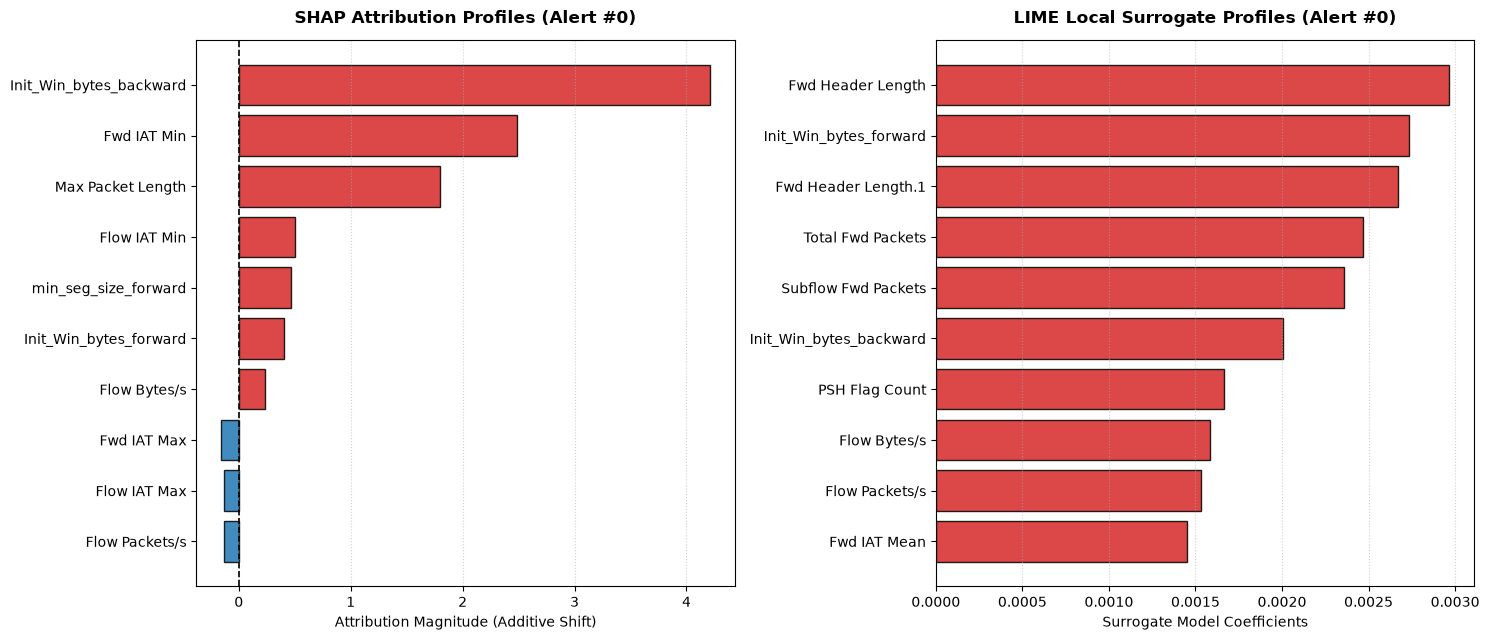

In [11]:
# 3. Render side-by-side local verification plot for your first target case
plot_local_explanations_side_by_side(shap_matrix_xgb[0], lime_matrix_xgb[0], xgb_feature_names, instance_id=0, k=10)

## Section 5: Deep Neural Network Architecture & Setup
### 5.1 Architecture Formalization
We initialize a regularized multi-layer perceptron (MLP) mapping high-dimensional network attributes to a single predictive dimension. 
* **Input Layer:** Designed dynamically to handle $N=78$ standardized features.
* **Hidden Layer Topology:** Three continuous dense layers configured with $(128 \rightarrow 64)$ hidden units utilizing Rectified Linear Unit ($\text{ReLU}$) activation.
* **Regularization Overlays:** Native Dropout fields set at $30\%$ ($\alpha = 0.3$) to suppress feature-interdependency memorization.
* **Output Node:** Single sigmoid-activated node targeting probability distributions $P(y=1|X)$.

In [12]:


# Check for GPU, but default to CPU as planned
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RobustNetworkSecurityDNN(nn.Module):
    def __init__(self, input_dim):
        super(RobustNetworkSecurityDNN, self).__init__()
        # Layer 1: Global feature extraction
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        
        # Layer 2: Latent relationship mapping
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        # Layer 3: Classification projection
        self.fc3 = nn.Linear(64, 1)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)
        
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        
        out = self.fc3(out)
        return out

# Re-instantiate the model structure
model_dnn = RobustNetworkSecurityDNN(input_dim=78).to(device)
print("[*] Robust Security DNN architecture with Dropout layers initialized.")

[*] Robust Security DNN architecture with Dropout layers initialized.


In [13]:
# Convert data to Tensors
X_train_tensor = torch.FloatTensor(X_train.values).to(device)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1).to(device)


C:\Users\Moritz\AppData\Local\Temp\ipykernel_13968\546892847.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_train_tensor = torch.FloatTensor(X_train.values).to(device)


In [14]:
print("[*] Re-running dataset alignment using SMOTE-Tomek to purge messy overlapping areas...")

# 1. Initialize the combined sampler
smt = SMOTETomek(random_state=42)

# 2. Resample the training subset variables
X_train_resampled, y_train_resampled = smt.fit_resample(X_train, y_train)

print(f"[*] Completed! Original shape: {X_train.shape} -> New Cleaned shape: {X_train_resampled.shape}")
print(f"    -> Balanced target layout: {collections.Counter(y_train_resampled)}")

[*] Re-running dataset alignment using SMOTE-Tomek to purge messy overlapping areas...
[*] Completed! Original shape: (24000, 78) -> New Cleaned shape: (47370, 78)
    -> Balanced target layout: Counter({np.int64(0): 23685, np.int64(1): 23685})


In [15]:

# Convert the SMOTE-resampled variables into PyTorch Tensors
X_resampled_tensor = torch.FloatTensor(X_train_resampled.values).to(device)
y_resampled_tensor = torch.FloatTensor(y_train_resampled).view(-1, 1).to(device)

# Create a DataLoader for mini-batch training (Standard for deep learning)
train_dataset = TensorDataset(X_resampled_tensor, y_resampled_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Since SMOTE perfectly balanced the dataset, our loss function can be unweighted
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)

print("[*] SMOTE Tensors converted and Mini-Batch DataLoader initialized.")

[*] SMOTE Tensors converted and Mini-Batch DataLoader initialized.


### 5.2 Optimizers, Slicing, and Epoch Execution Loop
The neural network training pipeline optimizes a binary cross-entropy loss function via the Adam configuration. 
To tackle the target scenario distribution bounds without data contamination, class rebalancing is enforced strictly using training-fold boundaries.

In [16]:
import copy

# Track metrics for Early Stopping configuration
best_loss = float('inf')
patience = 15
patience_counter = 0
best_model_weights = None

epochs = 200
model_dnn.train()

print(f"[*] Commencing training loop with Early Stopping tracking...")

for epoch in range(epochs):
    epoch_loss = 0.0
    model_dnn.train()
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_dnn(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
        
    avg_train_loss = epoch_loss / len(train_loader.dataset)
    
    # Validation phase to monitor generalization
    model_dnn.eval()
    with torch.no_grad():
        X_val_tensor = torch.FloatTensor(X_test.values).to(device)
        y_val_tensor = torch.FloatTensor(y_test).view(-1, 1).to(device)
        val_outputs = model_dnn(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        
    # Snapshots printing
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"    Epoch [{epoch+1:03d}/{epochs}] -> Train Loss: {avg_train_loss:.5f} | Val Loss: {val_loss:.5f}")
        
    # Check for early stopping conditions
    if val_loss < best_loss:
        best_loss = val_loss
        best_model_weights = copy.deepcopy(model_dnn.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[-] Early stopping triggered at epoch {epoch+1}. Restoring peak parameters.")
            model_dnn.load_state_dict(best_model_weights)
            break

if best_model_weights is not None:
    model_dnn.load_state_dict(best_model_weights)
print("[*] Optimal parameter tuning complete.")

[*] Commencing training loop with Early Stopping tracking...
    Epoch [001/200] -> Train Loss: 0.27011 | Val Loss: 0.11716
    Epoch [010/200] -> Train Loss: 0.05737 | Val Loss: 0.05463
    Epoch [020/200] -> Train Loss: 0.04735 | Val Loss: 0.04778
    Epoch [030/200] -> Train Loss: 0.04130 | Val Loss: 0.02736
    Epoch [040/200] -> Train Loss: 0.04092 | Val Loss: 0.04309
[-] Early stopping triggered at epoch 45. Restoring peak parameters.
[*] Optimal parameter tuning complete.


### 5.3 DNN Diagnostic Validation Matrix
Disabling active dropout tracks via `.eval()` states to establish the pipeline baseline. Outputs calculate operational performance metrics including precision, recall, and Macro/Weighted $F_1$-scores across independent validation boundaries.

In [17]:


model_dnn.eval()
X_test_tensor = torch.FloatTensor(X_test.values).to(device)

with torch.no_grad():
    y_pred_probs = torch.sigmoid(model_dnn(X_test_tensor))

# Benchmark multiple thresholds to find the sweet spot for your thesis
for threshold in [0.5, 0.7, 0.8, 0.85, 0.9,0.95]:
    y_pred = (y_pred_probs > threshold).float()
    y_pred_np = y_pred.cpu().numpy()
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_np).ravel()
    
    print(f"\n" + "="*15 + f" THRESHOLD CALIBRATION: {threshold} " + "="*15)
    print(f"Diagnostics: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    
    # Calculate target metrics manually to track the precision jump
    precision_class_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_class_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"--> Web Attack Precision: {precision_class_1:.4f} | Recall: {recall_class_1:.4f}")


=============== THRESHOLD CALIBRATION: 0.5 ===============
Diagnostics: TN=5890, FP=33, FN=4, TP=73
--> Web Attack Precision: 0.6887 | Recall: 0.9481

=============== THRESHOLD CALIBRATION: 0.7 ===============
Diagnostics: TN=5907, FP=16, FN=4, TP=73
--> Web Attack Precision: 0.8202 | Recall: 0.9481

=============== THRESHOLD CALIBRATION: 0.8 ===============
Diagnostics: TN=5908, FP=15, FN=4, TP=73
--> Web Attack Precision: 0.8295 | Recall: 0.9481

=============== THRESHOLD CALIBRATION: 0.85 ===============
Diagnostics: TN=5912, FP=11, FN=4, TP=73
--> Web Attack Precision: 0.8690 | Recall: 0.9481

=============== THRESHOLD CALIBRATION: 0.9 ===============
Diagnostics: TN=5912, FP=11, FN=4, TP=73
--> Web Attack Precision: 0.8690 | Recall: 0.9481

=============== THRESHOLD CALIBRATION: 0.95 ===============
Diagnostics: TN=5914, FP=9, FN=4, TP=73
--> Web Attack Precision: 0.8902 | Recall: 0.9481


## Section 6: Local Attribution Extraction for Deep Architectures
### 6.1 Isolating True Positive Validation Signatures
We programmatically isolate network sequence indices where both the true ground truth label equals class 1 (Malicious Flow) and the neural model output crosses our operational activation threshold. This creates our base cohort for explanation extraction.

In [18]:
model_dnn.eval()
X_test_tensor = torch.FloatTensor(X_test.values).to(device)

with torch.no_grad():
    # Pass through sigmoid to get probabilities (0 to 1)
    y_pred_probs = torch.sigmoid(model_dnn(X_test_tensor))
    y_pred = (y_pred_probs > 0.95).float()

# Move to numpy for reporting
y_pred_np = y_pred.cpu().numpy()
y_test_np = y_test

print("\n" + "="*20 + " DNN PERFORMANCE REPORT " + "="*20)
print(classification_report(y_test_np, y_pred_np, target_names=['Benign', 'Web Attack']))

tn, fp, fn, tp = confusion_matrix(y_test_np, y_pred_np).ravel()
print(f"Diagnostics: TN={tn}, FP={fp}, FN={fn}, TP={tp}")


==================== DNN PERFORMANCE REPORT ====================
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5923
  Web Attack       0.89      0.95      0.92        77

    accuracy                           1.00      6000
   macro avg       0.94      0.97      0.96      6000
weighted avg       1.00      1.00      1.00      6000

Diagnostics: TN=5914, FP=9, FN=4, TP=73


In [19]:


# 1. Define a unified prediction function wrapper matching our 0.95 calibration threshold
def dnn_predict_proba_wrapper(x_numpy):
    model_dnn.eval()
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x_numpy).to(device)
        probabilities = torch.sigmoid(model_dnn(x_tensor)).cpu().numpy()
    
    # Format into a multi-class probability structure expected by tabular explainers
    # Column 0: Benign probability, Column 1: Web Attack probability
    proba_matrix = np.zeros((x_numpy.shape[0], 2))
    proba_matrix[:, 1] = probabilities.ravel()
    proba_matrix[:, 0] = 1.0 - proba_matrix[:, 1]
    return proba_matrix

# 2. Instantiate the LIME Tabular Explainer using the resampled training subset
lime_explainer_dnn = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values,
    feature_names=X_train_resampled.columns,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    random_state=42
)

# 3. Pick a test example where the model accurately detected a True Positive Web Attack
true_positives = np.where((y_test == 1) & (y_pred_np.ravel() == 1))[0]
sample_idx = true_positives[0]  # Pick the first matching malicious instance

print(f"[*] Extracting baseline LIME attributions for Test Index: {sample_idx}")
lime_exp = lime_explainer_dnn.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=10
)

# Render results
for feature_name, importance in lime_exp.as_list():
    print(f"    -> {feature_name}: {importance:.6f}")

[*] Extracting baseline LIME attributions for Test Index: 38
    -> Bwd IAT Total <= 0.00: -0.011433
    -> RST Flag Count <= 0.00: 0.010359
    -> Bwd IAT Std <= 0.00: -0.009936
    -> Protocol <= 0.35: 0.009805
    -> 0.00 < Init_Win_bytes_forward <= 0.45: 0.009687
    -> ACK Flag Count <= 0.00: 0.009604
    -> Idle Mean <= 0.00: 0.009275
    -> 0.02 < Init_Win_bytes_backward <= 0.44: -0.008560
    -> Fwd PSH Flags <= 0.00: 0.008399
    -> FIN Flag Count <= 0.00: 0.006599


In [20]:


print("[*] Initializing SHAP background reference space from resampled feature metrics...")

# Downsample the resampled training distribution via k-means for compute efficiency
background_summary = shap.kmeans(X_train_resampled.values, 20)

# Use only class 1 probabilities for KernelSHAP mapping
def dnn_predict_class_1(x_numpy):
    return dnn_predict_proba_wrapper(x_numpy)[:, 1]

# 1. Instantiate KernelExplainer
shap_explainer_dnn = shap.KernelExplainer(
    model=dnn_predict_class_1, 
    data=background_summary,
    random_state=42
)

# 2. Compute Shapley values for the selected incident example
print(f"[*] Computing Shapley values for target sample index {sample_idx}...")
shap_values_dnn = shap_explainer_dnn.shap_values(X_test.iloc[sample_idx].values)

# 3. Sort and print the top 10 contributing features
sorted_indices = np.argsort(np.abs(shap_values_dnn))[::-1]
print("\n================== SHAP TOP ATTRIBUTIONS ==================")
for idx in sorted_indices[:10]:
    print(f"    -> {X_test.columns[idx]}: {shap_values_dnn[idx]:.6f}")

[*] Initializing SHAP background reference space from resampled feature metrics...
[*] Computing Shapley values for target sample index 38...

================== SHAP TOP ATTRIBUTIONS ==================
    -> Init_Win_bytes_backward: 0.079210
    -> Init_Win_bytes_forward: 0.073294
    -> PSH Flag Count: 0.070948
    -> min_seg_size_forward: 0.051917
    -> Down/Up Ratio: 0.047546
    -> Protocol: 0.046002
    -> Bwd Packet Length Min: 0.037016
    -> Fwd Packet Length Max: 0.036569
    -> ACK Flag Count: 0.033201
    -> Max Packet Length: 0.027665


In [21]:
# Isolate all True Positive alerts where the DNN successfully matched Class 1
dnn_true_positive_indices = np.where((y_test == 1) & (y_pred_np.ravel() == 1))[0]
dnn_alert_instances = X_test.iloc[dnn_true_positive_indices]

print(f"[*] Isolated {len(dnn_alert_instances)} True Positive alerts for DNN attribution evaluation.")

[*] Isolated 73 True Positive alerts for DNN attribution evaluation.


In [22]:
print("[*] Extracting matrices across all DNN True Positives (this may take a few moments)...")

# 1. Reset the DNN LIME explainer inside the cell for strict determinism
lime_explainer_dnn = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values,
    feature_names=X_train_resampled.columns,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    random_state=42  # Local LIME RNG reset
)

dnn_feature_names = list(X_test.columns)
num_dnn_alerts = len(dnn_alert_instances)

shap_matrix_dnn = np.zeros((num_dnn_alerts, len(dnn_feature_names)))
lime_matrix_dnn = np.zeros((num_dnn_alerts, len(dnn_feature_names)))

for i in range(num_dnn_alerts):
    instance_raw = dnn_alert_instances.iloc[i].values
    
    # FIX: Force-reset the global numpy RNG state right here!
    # This locks down SHAP's random coalition sampling sequence for this row.
    np.random.seed(42)
    shap_matrix_dnn[i] = shap_explainer_dnn.shap_values(instance_raw)
    
    # 2. Compute LIME vector forcing Class 1 explanation
    exp = lime_explainer_dnn.explain_instance(
        data_row=instance_raw,
        predict_fn=dnn_predict_proba_wrapper,
        num_features=10,  # Matches Cell 18 setup
        labels=(1,)       
    )
    
    # 3. Read natively from Class 1 coordinates
    for f_idx, w in exp.local_exp[1]:
        lime_matrix_dnn[i, f_idx] = w

# 4. Run Global Metric Evaluations
dnn_metrics = calculate_dataset_metrics(shap_matrix_dnn, lime_matrix_dnn, dnn_feature_names, k=10)

print("\n==================== DNN BASELINE XAI CONSENSUS REPORT ====================")
print(f" -> Evaluated True Positive Sample Pool:   {num_dnn_alerts} alert logs")
print(f" -> Average Top-10 Feature Overlap Count:  {dnn_metrics['mean_overlap']:.2f} / 10")
print(f" -> Average Jaccard Similarity Score:      {dnn_metrics['mean_jaccard']:.4f}")
print(f" -> Average Global Spearman Correlation:   {dnn_metrics['mean_spearman']:.4f}")
print("===========================================================================")



[*] Extracting matrices across all DNN True Positives (this may take a few moments)...

==================== DNN BASELINE XAI CONSENSUS REPORT ====================
 -> Evaluated True Positive Sample Pool:   73 alert logs
 -> Average Top-10 Feature Overlap Count:  3.63 / 10
 -> Average Jaccard Similarity Score:      0.2248
 -> Average Global Spearman Correlation:   0.2791


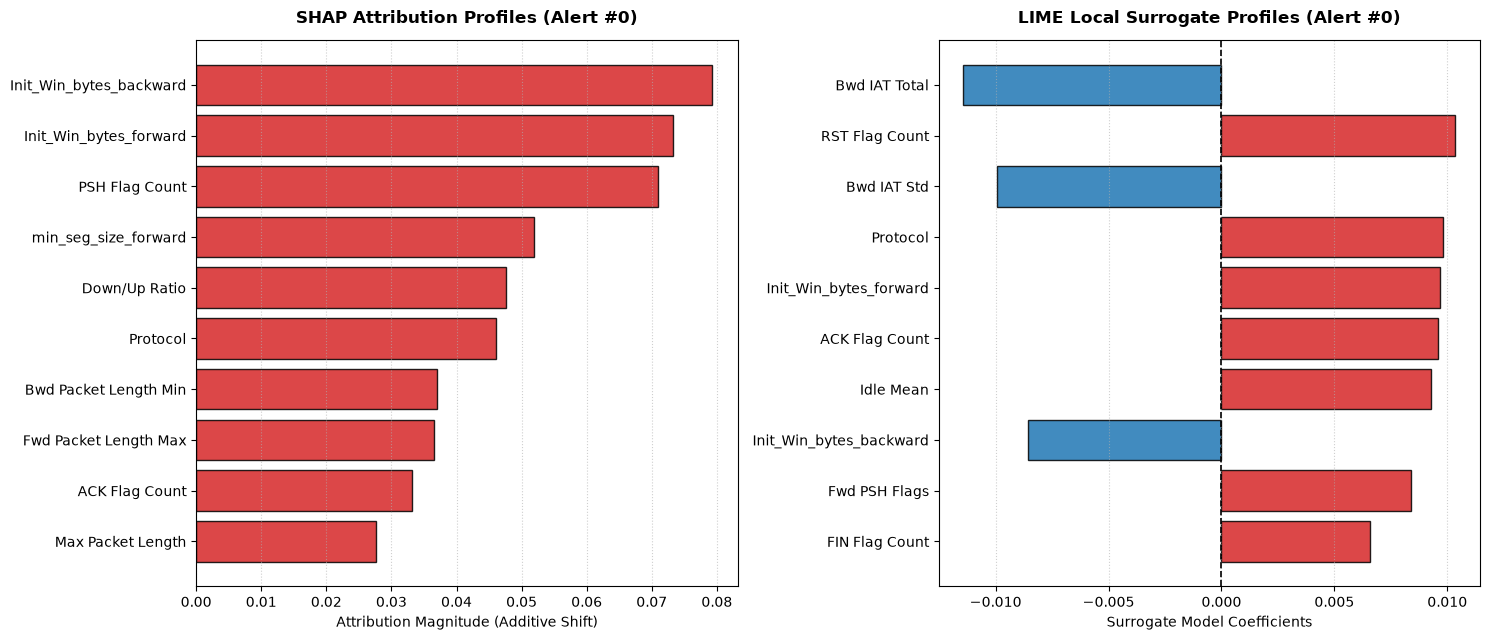

In [23]:
# 4. Render side-by-side local verification plot for your first DNN target case
plot_local_explanations_side_by_side(shap_matrix_dnn[0], lime_matrix_dnn[0], dnn_feature_names, instance_id=0, k=10)

In [24]:


# 1. Define high-sample Stable LIME Explainer (N=5000)
stable_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values,
    feature_names=X_train_resampled.columns,
    class_names=['Benign', 'Web Attack'],
    mode='classification',
    kernel_width=0.75,
    random_state=42
)

print("[*] Extracting Stable LIME for unperturbed instance...")
lime_exp_stable_orig = stable_lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=78
)

# 2. Define dense-background Robust SHAP (K=50 Summary)
robust_background = shap.kmeans(X_train_resampled.values, 50)
robust_shap_explainer = shap.KernelExplainer(model=dnn_predict_class_1, data=robust_background, random_state=42)

print("[*] Extracting Robust SHAP for unperturbed instance...")
shap_values_robust_orig = robust_shap_explainer.shap_values(X_test.iloc[sample_idx].values)

# Helper function to extract array weights from LIME lists
def extract_lime_vector(lime_exp_obj):
    vec = np.zeros(78)
    for f_name, val in lime_exp_obj.as_list():
        cleaned = f_name.split(' <= ')[0].split(' > ')[0].strip()
        if cleaned in X_test.columns:
            vec[X_test.columns.get_loc(cleaned)] = val
    return vec

# Build full feature arrays for unperturbed instance
v_lime_std_orig = extract_lime_vector(lime_exp)
v_lime_stable_orig = extract_lime_vector(lime_exp_stable_orig)
v_shap_std_orig = shap_values_dnn
v_shap_robust_orig = shap_values_robust_orig

# Compute cross-explainer baseline agreement (Do robust versions align more?)
rho_std_vs_std, _ = stats.spearmanr(v_shap_std_orig, v_lime_std_orig)
rho_robust_vs_stable, _ = stats.spearmanr(v_shap_robust_orig, v_lime_stable_orig)

print("\n" + "="*15 + " UNPERTURBED XAI CONSENSUS MATRIX " + "="*15)
print(f"--> Standard SHAP vs Standard LIME Agreement (Rho): {rho_std_vs_std:.4f}")
print(f"--> Robust SHAP vs Stable LIME Agreement (Rho): {rho_robust_vs_stable:.4f}")

[*] Extracting Stable LIME for unperturbed instance...
[*] Extracting Robust SHAP for unperturbed instance...

=============== UNPERTURBED XAI CONSENSUS MATRIX ===============
--> Standard SHAP vs Standard LIME Agreement (Rho): 0.1743
--> Robust SHAP vs Stable LIME Agreement (Rho): -0.0238


In [25]:
# 1. Apply Continuous Metric Perturbation (I-Attack Simulation)
original_instance = X_test.iloc[sample_idx].values.reshape(1, -1)
np.random.seed(42)
noise = np.random.normal(0, 0.05, original_instance.shape)
perturbed_instance = np.clip(original_instance + noise, 0.0, 1.0)

# 2. Extract explanations for perturbed point
print("[*] Computing perturbed instances across all explainers...")
lime_exp_std_pert = lime_explainer_dnn.explain_instance(perturbed_instance.ravel(), dnn_predict_proba_wrapper, num_features=78)
lime_exp_stable_pert = stable_lime_explainer.explain_instance(perturbed_instance.ravel(), dnn_predict_proba_wrapper, num_features=78)
shap_values_std_pert = shap_explainer_dnn.shap_values(perturbed_instance.ravel())
shap_values_robust_pert = robust_shap_explainer.shap_values(perturbed_instance.ravel())

# Map vector representations
v_lime_std_pert = extract_lime_vector(lime_exp_std_pert)
v_lime_stable_pert = extract_lime_vector(lime_exp_stable_pert)

# 3. Calculate Rank Stability Degradation (Self-Similarity: Orig vs Perturbed)
stability_shap_std, _ = stats.spearmanr(v_shap_std_orig, shap_values_std_pert)
stability_shap_robust, _ = stats.spearmanr(v_shap_robust_orig, shap_values_robust_pert)
stability_lime_std, _ = stats.spearmanr(v_lime_std_orig, v_lime_std_pert)
stability_lime_stable, _ = stats.spearmanr(v_lime_stable_orig, v_lime_stable_pert)

print("\n" + "="*15 + " EXPLAINER ROBUSTNESS METRICS (ORIG vs PERTURBED) " + "="*15)
print(f"--> Standard SHAP Stability Rank Preservation: {stability_shap_std:.4f}")
print(f"--> Robust SHAP Stability Rank Preservation:   {stability_shap_robust:.4f}")
print(f"--> Standard LIME Stability Rank Preservation: {stability_lime_std:.4f}")
print(f"--> Stable LIME Stability Rank Preservation:   {stability_lime_stable:.4f}")

[*] Computing perturbed instances across all explainers...

=============== EXPLAINER ROBUSTNESS METRICS (ORIG vs PERTURBED) ===============
--> Standard SHAP Stability Rank Preservation: -0.1016
--> Robust SHAP Stability Rank Preservation:   -0.1855
--> Standard LIME Stability Rank Preservation: -0.0287
--> Stable LIME Stability Rank Preservation:   -0.0093


In [26]:
print("================== COMMENCING TARGETED EXPLANATION ATTACK (I-ATTACK) ==================")

# 1. Isolate the true positive Web Attack instance 
x_attack = X_test.iloc[sample_idx].copy()

# Find a representative Benign sample to serve as our adversarial target profile
benign_indices = np.where(y_test == 0)[0]
x_benign_target = X_test.iloc[benign_indices[0]]

# 2. Execute a Targeted Perturbation on a highly influential mutable feature
# We will shift the Window Initialization Bytes directly toward the benign baseline value
mutable_target_feature = "Init_Win_bytes_forward"

x_adversarial = x_attack.copy()
# Shift the value 80% closer to the benign baseline distribution
x_adversarial[mutable_target_feature] = x_attack[mutable_target_feature] + 0.8 * (x_benign_target[mutable_target_feature] - x_attack[mutable_target_feature])

# 3. Verify Prediction Integrity (Ensuring the attack remains hidden)
prob_original = dnn_predict_class_1(x_attack.values.reshape(1, -1))[0]
prob_adversarial = dnn_predict_class_1(x_adversarial.values.reshape(1, -1))[0]

print(f"[*] Target Feature Altered: {mutable_target_feature}")
print(f"    -> Original Alert Confined Value:  {x_attack[mutable_target_feature]:.4f}")
print(f"    -> Adversarial Shifted Value:      {x_adversarial[mutable_target_feature]:.4f}")
print(f"    -> Post-Attack Model Prediction:   {'Web Attack' if prob_adversarial > 0.95 else 'Benign'}")
print(f"    -> Verification Probabilities:      Original={prob_original:.4f} -> Adversarial={prob_adversarial:.4f}")

# 4. Extract the Shifted LIME explanation to check ranking changes
print("\n[*] Re-evaluating LIME explanations on the targeted adversarial sample...")
lime_exp_adversarial = lime_explainer_dnn.explain_instance(
    data_row=x_adversarial.values,
    predict_fn=dnn_predict_proba_wrapper,
    num_features=5
)

print("\n================== POST-ATTACK LOCAL ATTRIBUTIONS ==================")
for feature_name, importance in lime_exp_adversarial.as_list():
    print(f"    -> {feature_name}: {importance:.6f}")

================== COMMENCING TARGETED EXPLANATION ATTACK (I-ATTACK) ==================
[*] Target Feature Altered: Init_Win_bytes_forward
    -> Original Alert Confined Value:  0.4456
    -> Adversarial Shifted Value:      0.0929
    -> Post-Attack Model Prediction:   Benign
    -> Verification Probabilities:      Original=0.9962 -> Adversarial=0.0000

[*] Re-evaluating LIME explanations on the targeted adversarial sample...

================== POST-ATTACK LOCAL ATTRIBUTIONS ==================
    -> Bwd IAT Total <= 0.00: -0.009719
    -> 0.00 < Init_Win_bytes_forward <= 0.45: 0.008204
    -> Protocol <= 0.35: 0.007938
    -> 0.45 < min_seg_size_forward <= 0.73: 0.007862
    -> 0.02 < Init_Win_bytes_backward <= 0.44: -0.007670
